# neuropt — LLM-guided Hyperparameter optimization

<a target="_blank" href="https://colab.research.google.com/github/loevlie/neuropt/blob/main/examples/neuropt_demo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**An LLM reads your training curves and designs your next experiment.**

neuropt uses an LLM to optimize hyperparameters and architectures. Unlike Optuna or random search, it sees *per-epoch training curves* — so it can spot overfitting, underfitting, and learning rate issues, then reason about what to try next.

This notebook shows two ways to use it:
1. **Define a search space** — you control what gets tuned
2. **Give it a model** — neuropt figures out what to tune

[![GitHub](https://img.shields.io/github/stars/loevlie/neuropt?style=social)](https://github.com/loevlie/neuropt)
[![PyPI](https://img.shields.io/pypi/v/neuropt)](https://pypi.org/project/neuropt/)

In [1]:
!pip install -q "neuropt[llm,torch]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 9.7 MB/s eta 0:00:00


In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_search(log_path, param_x="lr", param_y="dropout"):
    """Visualize a neuropt search: convergence, parameter exploration, best & worst training curves."""
    with open(log_path) as f:
        rows = [json.loads(line) for line in f if line.strip()]

    scores = [r["score"] for r in rows]
    configs = [r["config"] for r in rows]
    curves = [r.get("curves", {}) for r in rows]

    # Best so far
    best_so_far, best = [], float("inf")
    for s in scores:
        if s < best: best = s
        best_so_far.append(best)

    # Find best two continuous params if defaults missing
    has_x = all(param_x in c for c in configs)
    has_y = all(param_y in c for c in configs)
    if not (has_x and has_y):
        continuous = {}
        for k in configs[0]:
            vals = [c.get(k) for c in configs if isinstance(c.get(k), (int, float))]
            if len(vals) == len(configs) and len(set(vals)) > 2:
                continuous[k] = np.std(vals) / (np.mean(vals) + 1e-9)
        top = sorted(continuous, key=continuous.get, reverse=True)
        param_x = top[0] if len(top) > 0 else param_x
        param_y = top[1] if len(top) > 1 else param_y

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    # ── Panel 1: Convergence ──
    ax = axes[0]
    evals = np.arange(1, len(scores) + 1)
    ax.scatter(evals, scores, c="#bdbdbd", s=40, zorder=3, label="each eval", alpha=0.7)
    ax.plot(evals, best_so_far, "o-", color="#d32f2f", linewidth=2.5, markersize=5,
            label="best so far", zorder=5)
    for i, (s, b) in enumerate(zip(scores, best_so_far)):
        if s == b:
            ax.scatter(i+1, s, color="#d32f2f", s=90, zorder=6, edgecolors="white", linewidth=1.5)
    ax.set_xlabel("Evaluation #")
    ax.set_ylabel("Validation Loss")
    ax.set_title("Convergence", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Parameter exploration ──
    ax = axes[1]
    xs = [c.get(param_x, 0) for c in configs]
    ys = [c.get(param_y, 0) for c in configs]
    vmin, vmax = min(scores), min(max(scores), np.percentile(scores, 90) * 1.5)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    capped = [min(s, vmax) for s in scores]
    sc = ax.scatter(xs, ys, c=capped, cmap="RdYlGn_r", norm=norm,
                    s=120, edgecolors="black", linewidth=0.7, zorder=4)
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.annotate(str(i+1), (x, y), fontsize=7, ha="center", va="center",
                    fontweight="bold", color="white", zorder=6)
    best_idx = int(np.argmin(scores))
    ax.scatter(xs[best_idx], ys[best_idx], marker="*", s=300,
              facecolors="none", edgecolors="white", linewidth=2, zorder=7)
    if param_x == "lr" or "lr" in param_x:
        ax.set_xscale("log")
    ax.set_xlabel(param_x)
    ax.set_ylabel(param_y)
    ax.set_title("Where the LLM searched", fontweight="bold")
    plt.colorbar(sc, ax=ax, label="Val Loss", shrink=0.85)

    # ── Panel 3 & 4: Best and worst training curves (separate y scales) ──
    best_i = int(np.argmin(scores))
    finite_scores = [(i, s) for i, s in enumerate(scores) if s < float("inf")]
    worst_i = max(finite_scores, key=lambda x: x[1])[0] if finite_scores else 0

    for ax, idx, title, color in [(axes[2], best_i, "Best config", "#2e7d32"),
                                   (axes[3], worst_i, "Worst config", "#c62828")]:
        tl = curves[idx].get("train_losses", [])
        vl = curves[idx].get("val_losses", [])
        epochs = range(1, len(tl) + 1)
        if tl: ax.plot(epochs, tl, "-", color=color, alpha=0.5, linewidth=1.5, label="train")
        if vl: ax.plot(epochs, vl, "-", color=color, linewidth=2, label="val")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{title} (score={scores[idx]:.3f})", fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✓ plot_search() defined")

✓ plot_search() defined


In [3]:
import os
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    print("✓ API key loaded from Colab Secrets")
except Exception:
    if not os.environ.get("ANTHROPIC_API_KEY"):
        import getpass
        os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("ANTHROPIC_API_KEY: ")
        print("✓ API key set")

ANTHROPIC_API_KEY: ··········
✓ API key set


## Option 1: Define a search space

You write a training function + tell neuropt what to search. It handles the rest.

In [4]:
import math
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Load FashionMNIST (small subset for fast iteration)
transform = T.Compose([T.Grayscale(3), T.Resize(32), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
train_ds = torchvision.datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
val_ds = torchvision.datasets.FashionMNIST("./data", train=False, download=True, transform=transform)
rng = np.random.default_rng(0)
train_loader = DataLoader(Subset(train_ds, rng.choice(len(train_ds), 5000, replace=False)),
                          batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(Subset(val_ds, rng.choice(len(val_ds), 1250, replace=False)),
                        batch_size=128, shuffle=False, num_workers=2)

Using device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.0MB/s]


In [5]:
ACTIVATIONS = {"relu": nn.ReLU, "gelu": nn.GELU, "leaky_relu": nn.LeakyReLU, "silu": nn.SiLU}
EPOCHS = 10

class ConfigurableCNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act = ACTIVATIONS[cfg["activation"]]
        self.blocks, self.projs, self.pools = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        self.use_res = cfg["use_residual"]
        prev, spatial = 3, 32

        for i in range(cfg["n_blocks"]):
            out = min(512, max(8, int(cfg["base_channels"] * cfg["channel_growth"] ** i)))
            layers = [nn.Conv2d(prev, out, cfg["kernel_size"], padding=cfg["kernel_size"]//2, bias=not cfg["use_batchnorm"])]
            if cfg["use_batchnorm"]: layers.append(nn.BatchNorm2d(out))
            layers.append(act())
            if cfg["dropout"] > 0: layers.append(nn.Dropout2d(cfg["dropout"]))
            self.blocks.append(nn.Sequential(*layers))
            self.projs.append(nn.Conv2d(prev, out, 1, bias=False) if self.use_res and prev != out
                              else (nn.Identity() if self.use_res else None))
            if (i+1) % cfg["pool_every"] == 0 and spatial > 2:
                self.pools.append(nn.MaxPool2d(2) if cfg["pool_type"] == "max" else nn.AvgPool2d(2))
                spatial //= 2
            else:
                self.pools.append(None)
            prev = out

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = (nn.Sequential(nn.Linear(prev, cfg["fc_hidden"]), act(), nn.Dropout(cfg["dropout"]),
                                   nn.Linear(cfg["fc_hidden"], 10))
                     if cfg["fc_hidden"] > 0 else nn.Linear(prev, 10))

    def forward(self, x):
        for blk, proj, pool in zip(self.blocks, self.projs, self.pools):
            h = blk(x)
            if self.use_res and proj is not None: h = h + proj(x)
            x = pool(h) if pool else h
        return self.head(self.gap(x).flatten(1))


def train_fn(config):
    try:
        model = ConfigurableCNN(config).to(DEVICE)
    except Exception as e:
        return {"score": float("inf"), "status": "build_error", "error": str(e)}

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt_name = config.get("optimizer", "adamw")
    if opt_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=config["lr"], momentum=0.9, weight_decay=config["wd"])
    elif opt_name == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["wd"])
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["wd"])

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss()
    train_losses, val_losses, val_accuracies = [], [], []

    for _ in range(EPOCHS):
        model.train()
        tl, tn = 0.0, 0
        for imgs, tgts in train_loader:
            imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(imgs), tgts)
            if math.isnan(loss.item()):
                return {"score": float("inf"), "status": "nan", "n_params": n_params,
                        "train_losses": train_losses, "val_losses": val_losses, "val_accuracies": val_accuracies}
            loss.backward(); opt.step()
            tl += loss.item() * imgs.size(0); tn += imgs.size(0)
        sched.step(); train_losses.append(tl / tn)

        model.eval()
        vl, vn, vc = 0.0, 0, 0
        with torch.no_grad():
            for imgs, tgts in val_loader:
                imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
                out = model(imgs)
                vl += crit(out, tgts).item() * imgs.size(0)
                vc += (out.argmax(1) == tgts).sum().item(); vn += imgs.size(0)
        val_losses.append(vl / vn); val_accuracies.append(vc / vn)

    return {"score": val_losses[-1], "accuracy": val_accuracies[-1], "n_params": n_params,
            "train_losses": train_losses, "val_losses": val_losses, "val_accuracies": val_accuracies}

print(f"✓ Model + train_fn defined ({EPOCHS} epochs per eval)")

✓ Model + train_fn defined (10 epochs per eval)


LLM-Guided Search
  Backend: ClaudeBackend
  Device: auto
  Batch size: 3
  Log: search.jsonl
  Max evals: 15

  [0.0] n_blocks=4 base_channels=32 channel_growth=1.500 kernel_size=3 activation=silu use_residual=True use_batchnorm=True dropout=0.200 pool_every=2 pool_type=avg fc_hidden=128 lr=5.00e-03 wd=1.00e-04 optimizer=adamw → 0.6848 (accuracy=0.7480 n_params=144,402) 27.4s [llm] *** NEW BEST ***
  [0.1] n_blocks=6 base_channels=48 channel_growth=1.800 kernel_size=5 activation=gelu use_residual=True use_batchnorm=True dropout=0.150 pool_every=1 pool_type=max fc_hidden=256 lr=2.00e-03 wd=5.00e-05 optimizer=adam → 0.3502 (accuracy=0.8736 n_params=12,063,784) 39.1s [llm] *** NEW BEST ***
  [0.2] n_blocks=3 base_channels=64 channel_growth=2.000 kernel_size=3 activation=leaky_relu use_residual=False use_batchnorm=False dropout=0.300 pool_every=2 pool_type=max fc_hidden=64 lr=0.010 wd=5.00e-04 optimizer=sgd → 2.0970 (accuracy=0.2016 n_params=387,914) 25.7s [llm]
  iter 0 done in 95.6s | b

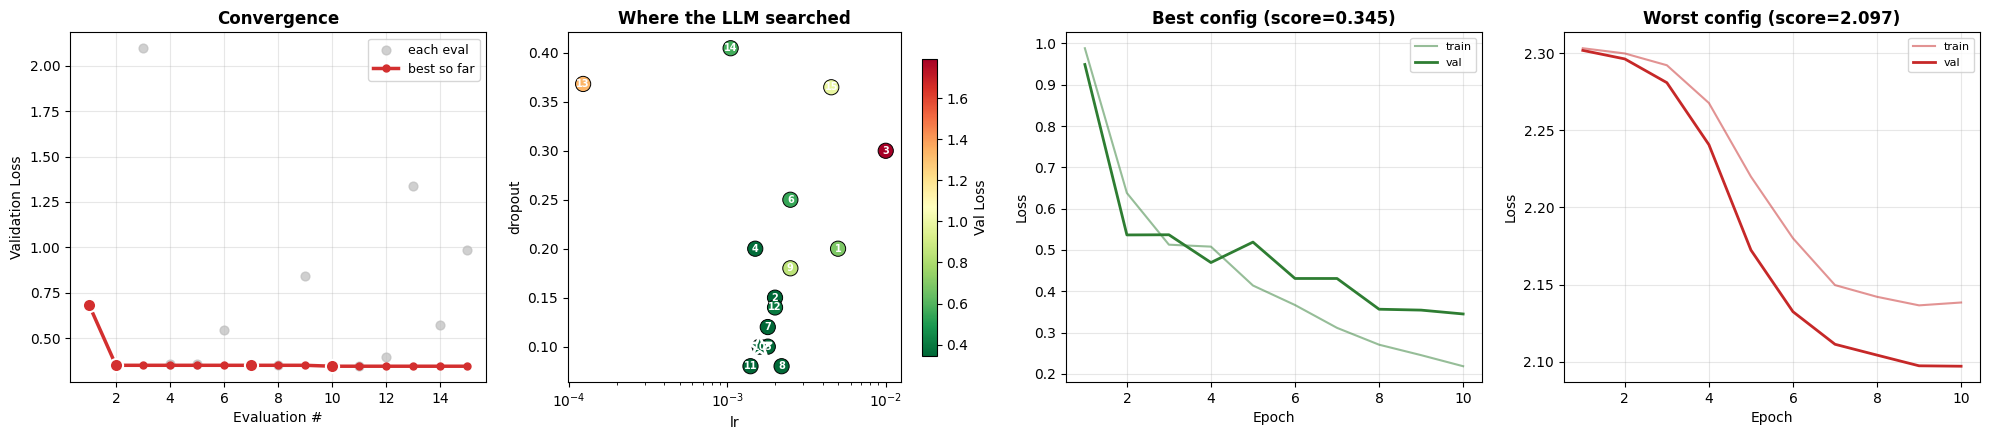

In [6]:
from neuropt import ArchSearch

search_space = {
    "n_blocks":       (2, 8),
    "base_channels":  (16, 128),
    "channel_growth": (1.0, 2.5),
    "kernel_size":    [3, 5],
    "activation":     ["relu", "gelu", "leaky_relu", "silu"],
    "use_residual":   [True, False],
    "use_batchnorm":  [True, False],
    "dropout":        (0.0, 0.5),
    "pool_every":     (1, 4),
    "pool_type":      ["max", "avg"],
    "fc_hidden":      (0, 512),
    "lr":             (1e-4, 0.1),
    "wd":             (1e-6, 0.01),
    "optimizer":      ["sgd", "adam", "adamw"],
}

search = ArchSearch(
    train_fn=train_fn,
    search_space=search_space,
    backend="claude",
)

search.run(max_evals=15, resume=False)  # fresh start
plot_search(search.log_path, param_x="lr", param_y="dropout")

### Keep going?

Results are saved to `search.jsonl` after every eval. Re-run the cell below to pick up where you left off.

In [ ]:
# Resumes automatically — runs 15 more evals from where you stopped
search.run(max_evals=15)
plot_search(search.log_path, param_x="lr", param_y="dropout")

## Option 2: Just give it a model

Don't want to define a search space? Hand neuropt a PyTorch model — it introspects the architecture, discovers what's tunable (activations, dropout, batch norm, pooling), and builds the search space for you.

In [ ]:
model = torchvision.models.resnet18(weights=None, num_classes=10)
model.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)  # adapt for 32x32
model.maxpool = nn.Identity()

def train_resnet(config):
    m = config["model"].to(DEVICE)
    opt_name = config.get("optimizer", "adamw")
    if opt_name == "sgd":
        opt = torch.optim.SGD(m.parameters(), lr=config["lr"], momentum=0.9, weight_decay=config["wd"])
    elif opt_name == "adam":
        opt = torch.optim.Adam(m.parameters(), lr=config["lr"], weight_decay=config["wd"])
    else:
        opt = torch.optim.AdamW(m.parameters(), lr=config["lr"], weight_decay=config["wd"])

    crit = nn.CrossEntropyLoss()
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5)
    train_losses, val_losses, val_accuracies = [], [], []

    for _ in range(5):
        m.train()
        tl, tn = 0.0, 0
        for imgs, tgts in train_loader:
            imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(imgs), tgts)
            loss.backward(); opt.step()
            tl += loss.item() * imgs.size(0); tn += imgs.size(0)
        sched.step(); train_losses.append(tl / tn)

        m.eval()
        vl, vn, vc = 0.0, 0, 0
        with torch.no_grad():
            for imgs, tgts in val_loader:
                imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
                out = m(imgs)
                vl += crit(out, tgts).item() * imgs.size(0)
                vc += (out.argmax(1) == tgts).sum().item(); vn += imgs.size(0)
        val_losses.append(vl / vn); val_accuracies.append(vc / vn)

    return {"score": val_losses[-1], "accuracy": val_accuracies[-1],
            "train_losses": train_losses, "val_losses": val_losses, "val_accuracies": val_accuracies}

# neuropt figures out the search space automatically
search2 = ArchSearch.from_model(model, train_resnet, backend="claude", log_path="search_resnet.jsonl")
search2.run(max_evals=10, resume=False)  # fresh start
plot_search(search2.log_path, param_x="lr", param_y="wd")

### Keep going?

Same idea — re-run the cell below to resume from `search_resnet.jsonl`.

In [ ]:
# Resumes automatically — runs 10 more evals from where you stopped
search2.run(max_evals=10)
plot_search(search2.log_path, param_x="lr", param_y="wd")

---

**What just happened?** neuropt used Claude Haiku (the cheapest Claude model) to read your training curves after each experiment and propose the next architecture to try. The summary above shows total API cost — typically a few cents for 15 evaluations.

**Next steps:**
- Try `max_evals=50` for better results
- Add `ml_context="..."` with domain knowledge about your task
- See the [docs](https://loevlie.github.io/neuropt/) for more options